# Soft Actor-Critic Implementation


Relevant equations from the paper are referenced in parentheses. Here's a recap:
- Maximum-entropy RL objective $(1)$
$$\mathcal{J}(\pi)
=
\sum_{t=0}^{\infty}
\mathbb{E}_{(s_t,a_t)\sim\rho_\pi}
\left[
r(s_t,a_t) + \alpha \mathcal{H}(\pi(\cdot \mid s_t))
\right]$$

- Soft Bellman backup $(2)$ -> Critic Target
$$Q^\pi(s_t,a_t)
=
r(s_t,a_t)
+
\gamma
\mathbb{E}_{s_{t+1} \sim p}
\left[
V^\pi(s_{t+1})
\right]$$

- Soft state value $(3)$ -> Value Network
$$V(s_t)
=
\mathbb{E}_{a_t\sim\pi}
\left[
Q(s_t,a_t) - \log \pi(a_t \mid s_t)
\right]$$


- Value loss $(5)$
$$\mathcal{J}_V(\psi)
=
\mathbb{E}_{s_t \sim \mathcal{D}}
\left[
\frac{1}{2}
\left(
V_\psi(s_t)
-
\mathbb{E}_{a_t \sim \pi_\phi}
\left[
Q_{\theta_i}(s_t,a_t)
-
\log \pi_\phi(a_t \mid s_t)
\right]
\right)^2
\right]$$

- Critic loss (soft Bellman residual) $(7,8)$
$$\mathcal{J}_Q(\theta)
=
\mathbb{E}_{(s_t,a_t)\sim\mathcal{D}}
\left[
\frac{1}{2}
\left(
Q_{\theta}(s_t,a_t)
-
\hat{Q}(s_t,a_t)
\right)^2
\right]$$
$$\hat{Q}(s_t,a_t)
=
r(s_t,a_t) + \gamma \mathbb{E_{s_{t+1}\sim\mathcal{p}}}{[V_{\bar{\psi}}(s_{t+1})]}$$

- Reparametrisation trick (action sampling) $(11)$
$$a_t = f_\phi(\epsilon_t; s_t),
\quad
\epsilon_t \sim \mathcal{N}(0, I)$$

- Policy loss with $a_t$ sampled as above $(12)$
$$\mathcal{J}_\pi(\phi)
=
\mathbb{E}_{s_t\sim\mathcal{D},\, a_t\sim\pi_\phi}
\left[
\log \pi_\phi(a_t \mid s_t)
-
Q_{\theta}(s_t,a_t)
\right]$$


- Action bounds $(21)$
$$\log \pi(a \mid s)
=
\log \mu(u \mid s)
-
\sum_{i}
\log\left(1 - \tanh^2(u_i)\right),
\quad
a = \tanh(u)$$

<!-- $$\hat{Q}(s_t,a_t)
=
r(s_t,a_t) + \gamma \mathbb{E_{s_{t+1}\sim\mathcal{p}}}{[V_{\bar{\psi}}(s_{t+1})]}
$$
$$
Q^*(s_t,a_t) = r(s_t,a_t) + \gamma \mathbb{E}_{s_{t+1}}[\max_{a_{t+1}} Q^*(s_t,a_t)]
$$ -->

In [142]:
import os
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions.normal import Normal

## Critic Network

Represents a $Q_{\theta}$ function and estimates expected return. Trained by minimising a Bellman residual $(7)$ using a target $(8)$. Other Q-learning methods use a `max` backup, but here "softness" is handled via the value function $V$, which includes the entropy term $(3)$.

**Two critics** are used to reduce positive bias and stabilise learning. We will then use $min(Q_{\theta_1},Q_{\theta_2})$ in the value and policy updates.

In [143]:
class CriticNetwork(nn.Module):
    def __init__(self, beta,  # learning rate
                 n_actions, input_dims, fc1_dims=256, fc2_dims=256,
                 name="critic", chkpt_dir='tmp/sac'):
        super(CriticNetwork, self).__init__()
        self.input_dims = input_dims
        self.fc1_dims = fc1_dims
        self.fc2_dims = fc2_dims
        self.n_actions = n_actions
        self.checkpoint_dir = chkpt_dir
        self.checkpoint_file = os.path.join(self.checkpoint_dir, name+'_sac')

        self.fc1 = nn.Linear(
            in_features=self.input_dims[0]+n_actions, # critic evaluates state-action pair!
            out_features=self.fc1_dims
        )
        self.fc2 = nn.Linear(self.fc1_dims, self.fc2_dims)
        self.q = nn.Linear(self.fc2_dims, 1) # scalar

        self.optimiser = optim.Adam(self.parameters(), lr=beta) # optimise over our params
        self.device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

        self.to(self.device)

    def forward(self, state, action):
        action_value = self.fc1(torch.cat([state, action], dim=1)) # concat state-action
        action_value = F.relu(action_value) # activation
        action_value = self.fc2(action_value)
        action_value = F.relu(action_value)

        q = self.q(action_value)

        return q

    def save_checkpoint(self):
        if not os.path.exists(self.checkpoint_dir):
            os.makedirs(self.checkpoint_dir)
        torch.save(self.state_dict(), self.checkpoint_file)

    def load_checkpoint(self):
        self.load_state_dict(torch.load(self.checkpoint_file))

## Value Network

Approximates the *soft state* value $(3)$. Training is done by regression via $(5)$.

The target value $V_{\bar{\psi}}(s)$ is updated with Polyak averaging for a slow-moving copy used inside the $Q$ target. $Q$ depends on $V$, so using a target value network avoids a feedback loop that can destabilise training.

Note: while the paper implements $V$ separately, modern implementations of SAC omit it and instead bootstrap directly from target $Q$ networks (compute from $Q$ and $\pi$ directly).


In [144]:
class ValueNetwork(nn.Module):
    def __init__(self, beta, 
                 input_dims, fc1_dims=256, fc2_dims=256,
                 name="value", chkpt_dir='tmp/sac'):
        super(ValueNetwork, self).__init__()
        self.input_dims = input_dims
        self.fc1_dims = fc1_dims
        self.fc2_dims = fc2_dims
        # no need for n_actions - value function is indep of actions
        self.checkpoint_dir = chkpt_dir
        self.checkpoint_file = os.path.join(self.checkpoint_dir, name+'_sac')

        self.fc1 = nn.Linear(*self.input_dims, self.fc1_dims)
        self.fc2 = nn.Linear(self.fc1_dims, self.fc2_dims)
        self.v = nn.Linear(self.fc2_dims, 1)

        self.optimiser = optim.Adam(self.parameters(), lr=beta)
        self.device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

        self.to(self.device)

    def forward(self, state):
        state_value = self.fc1(state)
        state_value = F.relu(state_value)
        state_value = self.fc2(state_value)
        state_value = F.relu(state_value)

        v = self.v(state_value)

        return v

    def save_checkpoint(self):
        if not os.path.exists(self.checkpoint_dir):
            os.makedirs(self.checkpoint_dir)
        torch.save(self.state_dict(), self.checkpoint_file)

    def load_checkpoint(self):
        self.load_state_dict(torch.load(self.checkpoint_file))

## Actor Network

Represents a stochastic policy $\pi_{\theta}(a|s)$ trained over the actor loss $(12)$ under the maximum entropy objective $(1)$.

Given a batch of states, it outputs the parameters of a diagonal Gaussian.

![title](img/actor_loss_equ.png)

Minimising $J_{\pi}(\theta)$ is equivalent to maximising the entropy objective $\mathbb{E}[Q(s,a) - log \pi (a|s)]$.

In [ ]:
class ActorNetwork(nn.Module):
    '''
    Sample a probability distribution with mean and covariance generated from the network
    (rather than a simple feed-forward operation).
    '''
    def __init__(self, alpha, # learning rate
                 input_dims, max_action,
                 fc1_dims=256, fc2_dims=256, n_actions=2,
                 name="actor", chkpt_dir="tmp/sac"
                 ):
        super(ActorNetwork, self).__init__()
        self.input_dims = input_dims
        self.fc1_dims = fc1_dims
        self.fc2_dims = fc2_dims
        self.n_actions = n_actions
        self.name = name
        self.checkpoint_dir = chkpt_dir
        self.checkpoint_file = os.path.join(self.checkpoint_dir, name+"_sac")
        self.max_action = max_action # for env action bounds
        self.reparam_noise = 1e-6

        # Define network layers - each network has 2 hidden layers
        self.fc1 = nn.Linear(*self.input_dims, self.fc1_dims)
        self.fc2 = nn.Linear(self.fc1_dims, self.fc2_dims)
        self.mu = nn.Linear(self.fc2_dims, self.n_actions) # mean of our policy's distribution 
        self.log_std = nn.Linear(self.fc2_dims, self.n_actions) # stdv

        self.optimiser = optim.Adam(self.parameters(), lr=alpha)
        self.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

        self.to(self.device)

        # paper does not mention any specific weight initialisation, so leave default (uniform)

    def forward(self, state):
        '''
        Specifies how data passes through the network.
        '''
        prob = self.fc1(state)
        prob = F.relu(prob)
        prob = self.fc2(prob)
        prob = F.relu(prob)

        mu=self.mu(prob)
        log_std = self.log_std(prob)

        log_std = torch.clamp(log_std, min=-20, max=2)

        return mu, log_std
    
    def sample_normal(self, state, reparametrise=True):
        mu, log_std = self.forward(state)
        std = torch.exp(log_std)
        
        if not torch.isfinite(mu).all():
            print("NaNs in mu", mu)
        if not torch.isfinite(std).all():
            print("NaNs in std", std)

        probabilities = Normal(mu, std)

        # Reparametrisation trick (equ. 11)
        if reparametrise:
            actions = probabilities.rsample() # so that a is differentiable
        else:
            actions = probabilities.sample() # if don't need gradients through sampled a

        # Enforcing action bounds (equ. 21, appendix C)
        u = actions
        a = torch.tanh(u) # in [-1, 1]

        log_probs = probabilities.log_prob(u) # for loss function (originally sampled actions)
        log_probs -= torch.log(1-a.pow(2) + self.reparam_noise) # avoid log(0)
        log_probs = log_probs.sum(1, keepdim=True) # to convert from n_actions dim to scalar
        
        # Rescale action to env bounds
        action = a * torch.tensor(self.max_action).to(self.device)

        return action, log_probs

    def save_checkpoint(self):
        if not os.path.exists(self.checkpoint_dir):
            os.makedirs(self.checkpoint_dir)
        torch.save(self.state_dict(), self.checkpoint_file)

    def load_checkpoint(self):
        self.load_state_dict(torch.load(self.checkpoint_file))


In [ ]:
class ReplayBuffer(object):
    def __init__(self, max_size, input_shape, n_actions):
        '''
        We want our buffer to store states, new states, actions, rewards, and terminal states.
        '''
        self.mem_size = max_size
        self.mem_counter = 0 # keep track of most recently saved memory
        self.state_memory = np.zeros((self.mem_size, *input_shape))
        self.action_memory = np.zeros((self.mem_size, n_actions))
        self.reward_memory = np.zeros(self.mem_size)
        self.new_state_memory = np.zeros((self.mem_size, *input_shape))
        self.terminal_memory = np.zeros(self.mem_size, dtype=np.float32)

    def store_transition(self, state, action, reward, new_state, done):
        index = self.mem_counter % self.mem_size # override oldest mems (wraps around)
        self.state_memory[index] = state
        self.action_memory[index] = action # note that actions themselves are arrays
        self.reward_memory[index] = reward
        self.new_state_memory[index] = new_state
        self.terminal_memory[index] = float(done)
        self.mem_counter += 1

    def sample_buffer(self, batch_size):
        max_mem = min(self.mem_counter, self.mem_size)
        batch = np.random.choice(max_mem, batch_size)

        states = self.state_memory[batch]
        actions = self.action_memory[batch]
        rewards = self.reward_memory[batch]
        new_states = self.new_state_memory[batch]
        dones = self.terminal_memory[batch]

        return states, actions, rewards, new_states, dones

## Training Loop: Agent
1. Collect off-policy transitions into the replay buffer
2. Perform gradient updates on the **value regression**, **twin critics** with a target value network, and the **stochastic policy**.

In [ ]:
class Agent():
    def __init__(self, alpha=0.0003, beta=0.0003, tau=0.005, input_dims=[3], env=None, gamma=0.99, 
                 n_actions=1, max_size=1000000, layer1_size=256, layer2_size=256, batch_size=256, 
                 reward_scale=2, chkpt_dir='tmp/sac'):
        '''
        Instantiate the following networks: one actor, two critic, one value, one target value.
        '''
        self.gamma = gamma
        self.tau = tau # for a soft copy
        self.memory = ReplayBuffer(max_size, input_dims, n_actions)
        self.batch_size = batch_size
        self.n_actions = n_actions
        
        self.actor = ActorNetwork(alpha, input_dims, max_action=env.action_space.high,
                                  n_actions=n_actions, name="actor", chkpt_dir=chkpt_dir)
        self.critic_1 = CriticNetwork(beta, n_actions, input_dims, name="critic_1")
        self.critic_2 = CriticNetwork(beta, n_actions, input_dims, name="critic_2")
        self.value = ValueNetwork(beta, input_dims, name="value")
        self.target_value = ValueNetwork(beta, input_dims, name="target_value")

        self.scale = reward_scale
        self.update_network_parameters(tau=1) # target is initialised to match V

    def choose_action(self, observation):
        '''
        Draw actions from the policy distribution:
            forward pass -> sample -> squash/scale to match env bounds
        '''
        state = torch.Tensor([observation]).to(self.actor.device) # convet obs to torch tensor
        actions, _ = self.actor.sample_normal(state, reparametrise=False)
        return actions.cpu().detach().numpy()[0] # take from cuda / graph to cpu
    
    def remember(self, state, action, reward, new_state, done):
        '''
        Store in buffer.
        '''
        self.memory.store_transition(state, action, reward, new_state, done)
    
    def update_network_parameters(self, tau=None):
        '''
        Slow updates on target value network.
        '''
        if tau is None:
            tau = self.tau

        with torch.no_grad():
            for target_param, param in zip(self.target_value.parameters(), self.value.parameters()):
                # Polyak update: target <- tau * online + (1 - tau) * target
                target_param.data.mul_(1.0 - tau)
                target_param.data.add_(tau * param.data)

    def save_models(self):
        print("Saving models...")
        self.actor.save_checkpoint()
        self.value.save_checkpoint()
        self.target_value.save_checkpoint()
        self.critic_1.save_checkpoint()
        self.critic_2.save_checkpoint()

    def load_models(self):
        print("Loading models...")
        self.actor.load_checkpoint()
        self.value.load_checkpoint()
        self.target_value.load_checkpoint()
        self.critic_1.load_checkpoint()
        self.critic_2.load_checkpoint()

    def learn(self):
        if self.memory.mem_counter < self.batch_size:
            return # not enough data
        
        # 1. Sample off-policy data
        state, action, reward, new_state, done = \
            self.memory.sample_buffer(self.batch_size)
        
        reward = torch.tensor(reward, dtype=torch.float).to(self.actor.device)
        done = torch.tensor(done, dtype=torch.long).to(self.actor.device)
        new_state = torch.tensor(new_state, dtype=torch.float).to(self.actor.device)
        state = torch.tensor(state, dtype=torch.float).to(self.actor.device)
        action = torch.tensor(action, dtype=torch.float).to(self.actor.device)

        # 2. Compute current and target state values
        value = self.value(state).view(-1) # collapse along batch dim (avoid tensor w/in tensor)
        new_value = self.target_value(new_state).view(-1)
        new_value[done] = 0.0

        # 3. Value update:
        #   sample action from current policy
        #   evaluate critics
        #   subtract log prob
        #   regress V to that target
        actions, log_probs = self.actor.sample_normal(state, reparametrise=False)
        log_probs = log_probs.view(-1)
        q1_new_policy = self.critic_1.forward(state, actions)
        q2_new_policy = self.critic_2.forward(state, actions)
        critic_value = torch.min(q1_new_policy, q2_new_policy)
        critic_value = critic_value.view(-1)

        self.value.optimiser.zero_grad()
        value_target = (critic_value - log_probs).detach() # equ. 3
            # (don't want gradients flowing into critics & actor)
        value_loss = 0.5 * F.mse_loss(value, value_target) # equ. 5 (squared residual error)
        value_loss.backward()
        self.value.optimiser.step()

        # 4. Actor update (improve policy w/ soft objective)
        actions, log_probs = self.actor.sample_normal(state, reparametrise=True)
            # want gradients to flow into the actor here!
        log_probs = log_probs.view(-1)
        q1_new_policy = self.critic_1.forward(state, actions)
        q2_new_policy = self.critic_2.forward(state, actions)
        critic_value = torch.min(q1_new_policy, q2_new_policy)
        critic_value = critic_value.view(-1)

        actor_loss = log_probs - critic_value
        actor_loss = torch.mean(actor_loss)
        self.actor.optimiser.zero_grad()
        actor_loss.backward()
        self.actor.optimiser.step()

        # 5. Critic udates (soft Bellman backup)
        self.critic_1.optimiser.zero_grad() # reset gradients
        self.critic_2.optimiser.zero_grad()
        q_hat = self.scale*reward + self.gamma*new_value # target value (equ. 8)
        q1_old_policy = self.critic_1.forward(state, action).view(-1) # action from replay buffer
        q2_old_policy = self.critic_2.forward(state, action).view(-1)
        critic_1_loss = 0.5 * F.mse_loss(q1_old_policy, q_hat) # equ. 7
        critic_2_loss = 0.5 * F.mse_loss(q2_old_policy, q_hat)

        critic_loss = critic_1_loss + critic_2_loss
        critic_loss.backward()
        self.critic_1.optimiser.step()
        self.critic_2.optimiser.step()

        self.update_network_parameters()

Note: reworked version of SAC (https://arxiv.org/abs/1812.05905) uses an "automatic gradient-based temperature tuning method that adjusts the expected entropy over the visited states to match a target value", after noticing brittleness induced by the temperature hyperparamenter.

In [148]:
def plot_learning_curve(scores, filename='plot.png', window=100):
    plt.figure(figsize=(12,6))
    plt.title('Training Performance')
    plt.xlabel('Episode')
    plt.ylabel('Score')

    plt.plot(scores, label='Score per episode')
    
    if len(scores) >= window:
        moving_avg = np.convolve(scores, np.ones(window)/window, mode='valid')
        plt.plot(range(window-1, len(scores)), moving_avg, 
                label=f'{window}-episode moving average', linewidth=2, color='red')

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(filename, dpi=100, bbox_inches='tight')
    plt.show()

In [149]:
def training_loop(env_name='Pendulum-v1', 
                  filename='pendulum', 
                  chkpt_dir='tmp/sac',
                  n_episodes=100,
                  max_steps=200,
                  video_frequency=20,
                  video_dir='videos'):
    env = gym.make(env_name)  # continuous action space
    agent = Agent(env=env, 
                  input_dims=env.observation_space.shape,
                  n_actions = env.action_space.shape[0], 
                  chkpt_dir=chkpt_dir)
    
    os.makedirs(video_dir, exist_ok=True)

    score_history = []
    best_avg_score = -np.inf
    np.random.seed(0)

    def record_video_episode(tag: str):
        venv = gym.make(env_name, render_mode="rgb_array")
        venv = RecordVideo(
            venv,
            video_folder=video_dir,
            name_prefix=f"{filename}_{tag}",
            episode_trigger=lambda ep: True  # record the first (and only) episode we run
        )

        s, _ = venv.reset()
        done = False
        steps = 0
        while not done and steps < max_steps:
            a = agent.choose_action(s)  # uses current policy
            s, r, terminated, truncated, info = venv.step(a)
            done = terminated or truncated
            steps += 1

        venv.close()

    # Training loop
    for episode in range(n_episodes):
        state, _ = env.reset()
        done = False
        score = 0
        step_count = 0
        max_steps = max_steps
        
        while not done and step_count < max_steps:
            action = agent.choose_action(state)
            new_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            agent.remember(state, action, reward, new_state, int(done))
            agent.learn()

            score += reward
            state = new_state
            step_count += 1

        score_history.append(score)

        # Average score
        if len(score_history) >= 10:
            avg_score = np.mean(score_history[-10:])
        else:
            avg_score = np.mean(score_history)
            
        print(f'episode {episode+1}/{n_episodes}, score: {score:.2f}, 10-ep. avg: {avg_score:.2f}')

        # Save best model
        if avg_score > best_avg_score:
            best_avg_score = avg_score
            agent.save_models()
            print(f'Saved new best model (best 10-ep. avg = {best_avg_score:.2f})')

        # Save video
        if (episode + 1) % video_frequency == 0:
            record_video_episode(tag=f"ep{episode+1:04d}_avg{avg_score:.2f}")
            print(f'Saved video at episode {episode+1}')

    filename = f'{filename}.png'
    plot_learning_curve(score_history, filename, window=10)

    # Final stats
    print(f"\nTraining completed for {n_episodes} episodes")
    print(f"Final 10-ep. average: {np.mean(score_history[-10:]):.2f}")
    print(f"Best score: {np.max(score_history):.2f}")

    env.close()

episode 1/100, score: -1296.31, 10-ep. avg: -1296.31
Saving models...
Saved new best model (best 10-ep. avg = -1296.31)
episode 2/100, score: -971.98, 10-ep. avg: -1134.15
Saving models...
Saved new best model (best 10-ep. avg = -1134.15)
episode 3/100, score: -1255.52, 10-ep. avg: -1174.60
episode 4/100, score: -1429.51, 10-ep. avg: -1238.33
episode 5/100, score: -1792.51, 10-ep. avg: -1349.17
episode 6/100, score: -1784.18, 10-ep. avg: -1421.67
episode 7/100, score: -1859.74, 10-ep. avg: -1484.25
episode 8/100, score: -1547.95, 10-ep. avg: -1492.21
episode 9/100, score: -1756.88, 10-ep. avg: -1521.62
episode 10/100, score: -1451.89, 10-ep. avg: -1514.65
episode 11/100, score: -1186.44, 10-ep. avg: -1503.66
episode 12/100, score: -1328.85, 10-ep. avg: -1539.35
episode 13/100, score: -1130.05, 10-ep. avg: -1526.80
episode 14/100, score: -988.91, 10-ep. avg: -1482.74
episode 15/100, score: -1193.99, 10-ep. avg: -1422.89
episode 16/100, score: -902.95, 10-ep. avg: -1334.77
episode 17/100

/opt/miniconda3/envs/sac_rl/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/const/Documents/CDT_D2AIR/self_learning/ImplementingRLPapers/SAC/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Saved video at episode 20
episode 21/100, score: -1202.08, 10-ep. avg: -1070.90
episode 22/100, score: -910.27, 10-ep. avg: -1029.04
Saving models...
Saved new best model (best 10-ep. avg = -1029.04)
episode 23/100, score: -1169.81, 10-ep. avg: -1033.01
episode 24/100, score: -1281.11, 10-ep. avg: -1062.23
episode 25/100, score: -1210.26, 10-ep. avg: -1063.86
episode 26/100, score: -1201.88, 10-ep. avg: -1093.75
episode 27/100, score: -1215.72, 10-ep. avg: -1124.92
episode 28/100, score: -1201.30, 10-ep. avg: -1156.81
episode 29/100, score: -959.69, 10-ep. avg: -1129.22
episode 30/100, score: -1271.05, 10-ep. avg: -1162.32
episode 31/100, score: -1167.57, 10-ep. avg: -1158.87
episode 32/100, score: -1060.54, 10-ep. avg: -1173.89
episode 33/100, score: -1079.38, 10-ep. avg: -1164.85
episode 34/100, score: -1056.34, 10-ep. avg: -1142.37
episode 35/100, score: -973.66, 10-ep. avg: -1118.71
episode 36/100, score: -886.61, 10-ep. avg: -1087.19
episode 37/100, score: -631.40, 10-ep. avg: -10

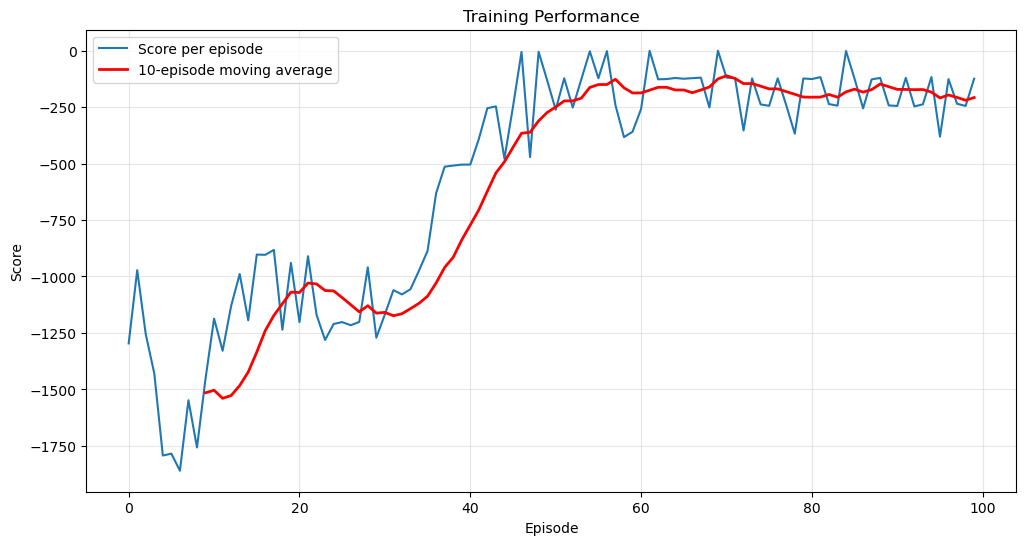


Training completed for 100 episodes
Final 10-ep. average: -208.15
Best score: -0.80


In [150]:
training_loop('Pendulum-v1', filename='pendulum', chkpt_dir='tmp/sac', video_dir='videos')